# 第 10 章 · 卷积代码实验

本页用手写数字图像观察卷积核如何提取边缘。读者先看原图和卷积核，再看每个窗口的计算值，最后看池化如何压缩特征图。

[章节网页](../ch10.html)

## 运行内容

- 加载 Digits 图像
- 计算 Sobel 卷积
- 绘制特征图

## 0. 图像与卷积核

输入图像是 8×8 灰度数字，Sobel 核会强调竖向边缘。卷积输出越大，表示该区域越像这个边缘模式。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 使用手写数字图像，配合 Sobel 核做边缘检测。
digits = load_digits()
image = digits.images[13] / 16.0
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

feature = correlate2d(image, kernel, mode="valid")
display(pd.DataFrame(image).round(2))
display(pd.DataFrame(kernel.astype(int)))

,0,1,2,3,4,5,6,7
0,0.0,0.12,0.56,0.94,0.88,0.56,0.19,0.0
1,0.0,0.25,0.81,0.50,0.56,1.00,0.50,0.0
2,0.0,0.00,0.00,0.38,0.88,0.94,0.19,0.0
3,0.0,0.00,0.00,0.69,0.88,0.12,0.00,0.0
4,0.0,0.00,0.00,0.12,0.94,0.69,0.00,0.0
5,0.0,0.00,0.00,0.00,0.12,0.94,0.25,0.0
6,0.0,0.06,0.31,0.38,0.81,1.00,0.38,0.0
7,0.0,0.12,0.75,0.75,0.81,0.69,0.00,0.0


,0,1,2
0,-1,0,1
1,-1,0,1
2,-1,0,1


## 1. 卷积与池化

卷积逐窗口计算局部模式，池化保留局部最强响应。把三张图连起来看，能看到图像如何逐步变成特征。

In [3]:
# 展开每个窗口的卷积值。
rows = []
for i in range(feature.shape[0]):
    for j in range(feature.shape[1]):
        window = image[i:i + 3, j:j + 3]
        rows.append({
            "位置": f"({i},{j})",
            "窗口": window.astype(int).tolist(),
            "卷积值": round(float((window * kernel).sum()), 3),
        })

conv_df = pd.DataFrame(rows)
display(conv_df.head(8))
display(pd.DataFrame(feature).round(3))

,位置,窗口,卷积值
0,"(0,0)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",1.375
1,"(0,1)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",1.438
2,"(0,2)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",0.938
3,"(0,3)","[[0, 0, 0], [0, 0, 1], [0, 0, 0]]",0.688
4,"(0,4)","[[0, 0, 0], [0, 1, 0], [0, 0, 0]]",-1.438
5,"(0,5)","[[0, 0, 0], [1, 0, 0], [0, 0, 0]]",-2.500
6,"(1,0)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",0.812
7,"(1,1)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",1.312


,0,1,2,3,4,5
0,1.375,1.438,0.938,0.688,-1.438,-2.500
1,0.812,1.312,1.500,0.500,-1.625,-2.062
2,0.000,1.188,2.688,0.562,-2.500,-1.750
3,0.000,0.812,1.938,0.938,-1.688,-1.750
4,0.312,0.438,1.562,2.125,-1.250,-2.625
5,1.062,0.938,0.688,1.500,-1.125,-2.625


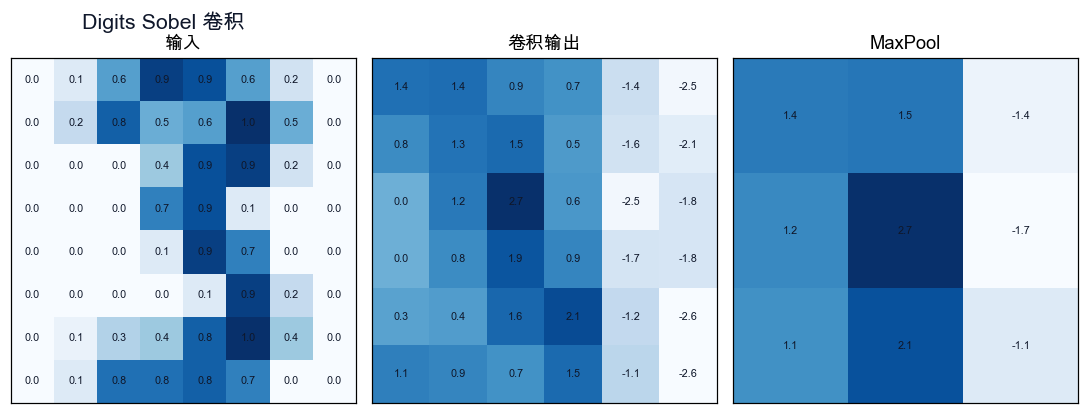

In [4]:
# 绘制输入、卷积输出和 2x2 max pooling。
pool = np.array([
    [feature[i:i + 2, j:j + 2].max() for j in range(0, feature.shape[1], 2)]
    for i in range(0, feature.shape[0], 2)
])

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.8))
for ax, data, title in zip(axes, [image, feature, pool], ["输入", "卷积输出", "MaxPool"]):
    im = ax.imshow(data, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.1f}", ha="center", va="center", color="#0f172a", fontsize=7)
fig.suptitle("Digits Sobel 卷积", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()